In [1]:
import os
from dotenv import load_dotenv

from PIL import Image

import torch
from ultralytics import YOLO
from roboflow import Roboflow

In [2]:
# YOLO11 es tan versátil que correrá en CPU, pero si tienes una GPU (NVIDIA CUDA) o Mac M1/M2 (MPS), la usaremos.
device = "cuda" if torch.cuda.is_available() else \
         "mps" if torch.backends.mps.is_available() else "cpu"

print(f"Dispositivo seleccionado para inferencia:\n{device}")

Dispositivo seleccionado para inferencia:
cuda


In [3]:
# 1. Cargamos las variables ocultas del archivo .env a nuestro entorno
load_dotenv()

True

In [4]:
os.getenv('TEST')

'Esto es un secreto! Nunca lo imprimas en tu código'

In [5]:
# 2. Extraemos la llave de forma segura
api_key_segura = os.getenv("ROBOFLOW_API_KEY")

if not api_key_segura:
    print("Error: No se encontró la API Key. Verifica tu archivo .env")
else:
    print("API KEY importada, nadie sabrá cuál es")

API KEY importada, nadie sabrá cuál es


In [6]:
# 3. Nos conectamos usando la variable, ¡nunca texto plano!
rf = Roboflow(api_key=api_key_segura) 

project = rf.workspace("efras-workspace-p8vm7").project("rocket-league-drqre-j1jru")

loading Roboflow workspace...
loading Roboflow project...


In [7]:
# Definimos la ruta donde queremos que se guarde
ruta_destino = "local/datasets/rocket_league"

# El formato oficial en la API de Roboflow para la familia moderna de YOLO es "yolov8"
dataset = project.version(1).download("yolov8", location=ruta_destino)

print(f"Dataset encontrado o descargado!")

Exporting format yolov8 in progress : 76.0%
Version export complete for yolov8 format



Extracting Dataset Version Zip to local/datasets/rocket_league in yolov8:: 100%|██████████| 1351/1351 [00:00<00:00, 1904.97it/s]

Dataset encontrado o descargado!


In [8]:
# Partimos de los pesos pre-entrenados locales
yolo_fine_tuning = YOLO("local/weights/yolo11n.pt")

In [9]:
# Ejecutamos el ciclo de entrenamiento
yolo_fine_tuning.train(
    data="local/datasets/rocket_league/data.yaml", 
    epochs=100,
    patience=15,
    imgsz=320,
    batch=8,
    device=device,
    plots=True
)

Ultralytics 8.4.33  Python-3.10.6 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3070 Laptop GPU, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=local/datasets/rocket_league/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=local/weights/yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000196D56A1E40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

In [10]:
# 1. Cargamos el modelo especializado (usamos 'best.pt' que es el resultado del fine-tuning)
model_rl = YOLO("local/runs/detect/train/weights/best.pt")

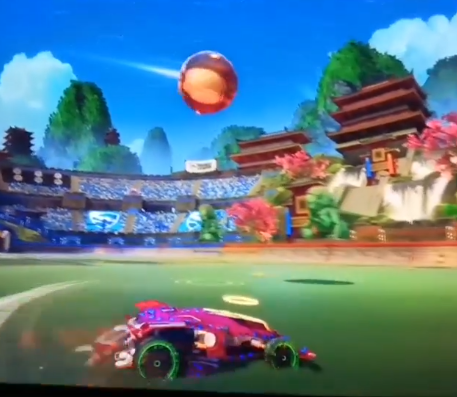

In [11]:
# 2. Usamos una imagen completamente nueva
img = Image.open(r"local\assets\sample_images\rocket-league-test.png")
img


0: 288x320 1 ball, 1 car, 29.4ms
Speed: 1.6ms preprocess, 29.4ms inference, 3.2ms postprocess per image at shape (1, 3, 288, 320)


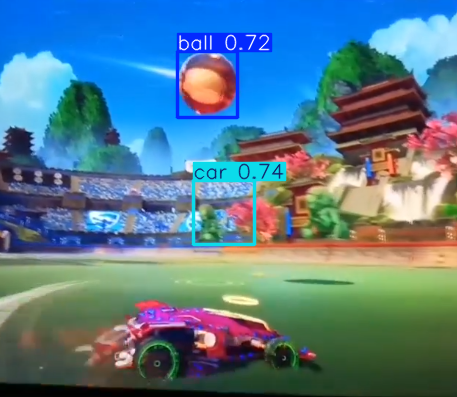

In [15]:
# 3. Ejecutamos la inferencia
# conf=0.5: Solo mostramos objetos con más del 50% de certeza
results = model_rl.predict(source=img, conf=0.7)

# 4. Visualizamos los resultados directamente en el notebook
Image.fromarray(results[0].plot()[..., ::-1])

In [ ]:
# # Esto guardará un nuevo .mp4 en la carpeta 'runs/detect/predict/' con todas las detecciones incrustadas
# results_video = model.predict(
#     source="local/assets/sample_videos/video_demo.mp4", 
#     save=True, 
#     conf=0.4, 
#     device=device
# )
# print("✅ ¡Video procesado exitosamente! Revisa la carpeta runs/detect/")